In [1]:
%load_ext autoreload
%reload_ext autoreload

%autoreload 2
%matplotlib inline

import math
import tensorflow
from tensorflow.compat.v1.keras.backend import get_session
tensorflow.compat.v1.disable_v2_behavior()
import kerasAC 
from kerasAC.generators.snp_generator import *
from kerasAC.tiledb_config import *
from scipy.special import softmax
from kerasAC.interpret.deepshap import * 
from kerasAC.interpret.profile_shap import * 
from kerasAC.vis import * 
from kerasAC.helpers.transform_bpnet_io import * 

Instructions for updating:
non-resource variables are not supported in the long term


Using TensorFlow backend.
/users/annashch/kerasAC/kerasAC/vis/plot_letters.py:172: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  min_coords = np.vstack(data.min(0) for data in polygons_data).min(0)
/users/annashch/kerasAC/kerasAC/vis/plot_letters.py:173: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  max_coords = np.vstack(data.max(0) for data in polygons_data).max(0)


In [3]:
import pyBigWig 
pbw=pyBigWig.open("/oak/stanford/groups/akundaje/projects/atlas/dnase_processed/dnase/13da5ebe-0941-4855-8599-40bbcc5c58b4/call-bowtie2/shard-0/execution/ENCSR000EMT.merged.bam.bpnet.unstranded.bw",'r')

In [4]:
#make sure the snp coordinate is 0-based
import pandas as pd 
snps=pd.read_csv("/srv/scratch/annashch/chrombpnet/gm12878_dnase/bQTL/pu1.txt",header=0,sep='\t')
keep1=snps.iloc[0:100]
keep2=snps.iloc[999699:999800]
snps=pd.concat((keep1,keep2),axis=0)
snps['Pos0']=snps['position']-1
snps['rsid']=snps['Chr'].astype(str)+'_'+snps['Pos0'].astype(str)+'_'+snps['POSTallele'].astype(str)+'_'+snps['ALTallele'].astype('str')
snps.to_csv("pu1.formatted.csv",header=True,index=False,sep='\t')
snps.head() 

,Chr,position,Depth,ALTdepth,REFDepth,ALTallele,POSTallele,POSTfreq,prechipfreq,pvalue,Pos0,rsid
0,chr17,18967176,538,418,120,G,A,0.223048,0.866699,2.331853e-251,18967175,chr17_18967175_A_G
1,chr4,176935913,626,597,29,A,C,0.046326,0.543949,4.449643e-162,176935912,chr4_176935912_C_A
2,chr1,144534083,618,368,250,T,C,0.404531,0.057295,5.863065e-141,144534082,chr1_144534082_C_T
3,chr17,19015381,144,143,1,A,T,0.006944,0.872850,1.040250e-126,19015380,chr17_19015380_T_A
4,chr1,17231724,2477,1321,1156,G,A,0.466694,0.255195,9.915948e-114,17231723,chr1_17231723_A_G


In [5]:
snps.shape

(200, 12)

In [6]:
#reference allele sequence generator 
ref_gen=SNPGenerator(bed_path="pu1.formatted.csv",
                 chrom_col="Chr",
                 pos_col="Pos0",
                 allele_col="POSTallele",
                 rsid_col='rsid',
                 flank_size=673,
                 ref_fasta="/mnt/data/male.hg19.fa",
                 expand_dims=False)

#alternate allele sequence generator 
alt_gen=SNPGenerator(bed_path="pu1.formatted.csv",
                 chrom_col="Chr",
                 pos_col="Pos0",
                 allele_col="ALTallele",
                 rsid_col='rsid',
                 flank_size=673,
                 ref_fasta="/mnt/data/male.hg19.fa",
                 expand_dims=False)


In [7]:
#load the model! 
from keras.models import load_model
from keras.utils.generic_utils import get_custom_objects
from kerasAC.metrics import * 
from kerasAC.custom_losses import * 
custom_objects={"recall":recall,
                    "sensitivity":recall,
                    "specificity":specificity,
                    "fpr":fpr,
                    "fnr":fnr,
                    "precision":precision,
                    "f1":f1,
                    "ambig_binary_crossentropy":ambig_binary_crossentropy,
                    "ambig_mean_absolute_error":ambig_mean_absolute_error,
                    "ambig_mean_squared_error":ambig_mean_squared_error,
                    "MultichannelMultinomialNLL":MultichannelMultinomialNLL}
get_custom_objects().update(custom_objects)
model=load_model("/srv/scratch/annashch/chrombpnet/gm12878_dnase/with_bias_bpnet_tobias/gm12878.dnase.with.bpnet.tobias.bias.0.hdf5")

Instructions for updating:
If using Keras pass *_constraint arguments to layers.


In [8]:
#get the reference allele predictions 
count_preds={} 
profile_preds={} 
snp_to_seq={} 
for i in range(len(ref_gen)):
    print(str(i))
    cur_x=ref_gen[i] 
    batch_rsids=cur_x[0] 
    batch_preds=model.predict(cur_x[1])
    batch_preds_profile=batch_preds[0]
    batch_preds_count=batch_preds[1] 
    for batch_index in range(len(batch_rsids)): 
        cur_rsid=batch_rsids[batch_index]
        snp_to_seq[cur_rsid]={} 
        snp_to_seq[cur_rsid]['ref']=cur_x[1][batch_index,:,:]
        cur_pred_profile=batch_preds_profile[batch_index,:,:]
        cur_pred_count=batch_preds_count[batch_index,:][0]
        count_preds[cur_rsid]={}
        count_preds[cur_rsid]['ref']=cur_pred_count
        profile_preds[cur_rsid]={}
        profile_preds[cur_rsid]['ref']=cur_pred_profile 

0


In [9]:
#get the alternate allele predictions 
for i in range(len(alt_gen)):
    print(str(i))
    cur_x=alt_gen[i] 
    batch_rsids=cur_x[0] 
    batch_preds=model.predict(cur_x[1])
    batch_preds_profile=batch_preds[0]
    batch_preds_count=batch_preds[1] 
    for batch_index in range(len(batch_rsids)): 
        cur_rsid=batch_rsids[batch_index]
        snp_to_seq[cur_rsid]['alt']=cur_x[1][batch_index,:,:]
        cur_pred_profile=batch_preds_profile[batch_index,:,:]
        cur_pred_count=batch_preds_count[batch_index,:][0]
        count_preds[cur_rsid]['alt']=cur_pred_count
        profile_preds[cur_rsid]['alt']=cur_pred_profile 

0


In [10]:
#convert dictionary to pandas df for easier manipulation 
count_preds_df=pd.DataFrame.from_dict(count_preds,orient='index')
count_preds_df['Alt_Minus_Ref']=count_preds_df['alt']-count_preds_df['ref']
#sort by difference 
count_preds_df=count_preds_df.sort_values(by=["Alt_Minus_Ref"])
count_preds_df.to_csv("pu1_count_predictions_alt_and_ref.tsv",header=True,index=True,sep='\t')

print(count_preds_df.head())
print(count_preds_df.tail())

                         ref       alt  Alt_Minus_Ref
chr10_5894499_A_G   6.893589  6.212861      -0.680728
chr9_140703690_G_T  6.192876  5.701864      -0.491012
chr5_150233303_C_A  5.816268  5.332742      -0.483526
chr4_42323014_G_T   6.740864  6.312389      -0.428475
chr7_31728179_T_C   6.636642  6.211155      -0.425486
                          ref       alt  Alt_Minus_Ref
chr10_105803155_G_T  6.054095  6.554228       0.500133
chr15_70174408_C_T   5.793444  6.399358       0.605914
chr18_45206448_G_A   5.532444  6.260502       0.728058
chr12_100552498_C_T  5.820693  6.596694       0.776001
chr4_37814568_C_T    5.744443  6.695909       0.951465


In [11]:
from scipy.special import softmax,logit,softmax
from scipy.spatial.distance import jensenshannon
#get the JSD for profile preds 
jsd_dict={} 
for rsid in profile_preds: 
    ref_preds=softmax(profile_preds[rsid]['ref'],axis=0)
    alt_preds=softmax(profile_preds[rsid]['alt'],axis=0)
    cur_jsd=jensenshannon(ref_preds.squeeze(),alt_preds.squeeze())
    jsd_dict[rsid]=cur_jsd
jsd_df=pd.DataFrame.from_dict(jsd_dict,orient='index')
jsd_df.head()
#sort by difference 
jsd_df=jsd_df.sort_values(by=[0])
jsd_df.to_csv("pu1_jsd_predictions.tsv",header=True,index=True,sep='\t')

print(jsd_df.head())
print(jsd_df.tail())


                           0
chr19_2598510_T_C   0.002427
chr22_22385609_C_T  0.007077
chr6_133135090_G_T  0.008170
chr3_150300757_A_T  0.008204
chr6_158251319_C_T  0.008216
                            0
chr12_100552498_C_T  0.138274
chr3_191100641_A_T   0.146745
chr14_22590585_A_T   0.166559
chr5_112577199_G_A   0.177595
chr5_14248206_G_T    0.224854


In [12]:
jsd_df['JSD']=jsd_df[0]
jsd_df=jsd_df.drop(columns=[0])
#merge the data frames
merged=pd.merge(jsd_df,count_preds_df,left_index=True,right_index=True)
merged=pd.merge(merged,snps,left_index=True,right_on=['rsid'])
merged['-log10P']=-1*np.log10(merged['pvalue'])

In [13]:
merged['sig']=merged['pvalue']<0.01
merged['color']='r'
merged['color'][merged['sig']==True]='b'

In [14]:
merged['logratio']=np.log((merged['POSTfreq'])/(merged['prechipfreq']))

In [15]:
%matplotlib inline

from plotnine import * 


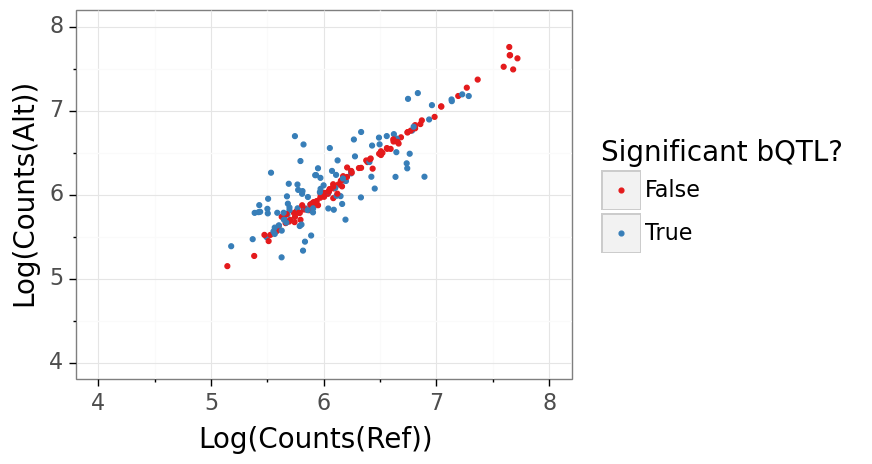

<ggplot: (8751430963329)>

In [16]:
(ggplot(merged, aes('ref', 'alt', color='factor(sig)'))
 + geom_point()
 + xlim(4,8)
 + ylim(4,8)
 + xlab("Log(Counts(Ref))")
 + ylab("Log(Counts(Alt))")
 + scale_color_manual(values=['#e41a1c','#377eb8'],name="Significant bQTL?")
 + theme_bw(20))


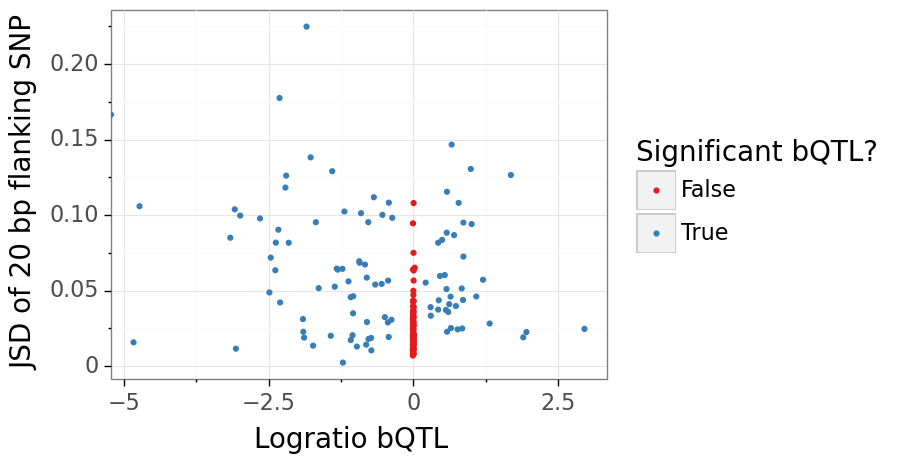

<ggplot: (8751430333693)>

In [17]:
(ggplot(merged, aes('logratio', 'JSD', color='factor(sig)'))
 + geom_point()

 + xlab("Logratio bQTL")
 + ylab("JSD of 20 bp flanking SNP")
 + scale_color_manual(values=['#e41a1c','#377eb8'],name="Significant bQTL?")
 + theme_bw(20))

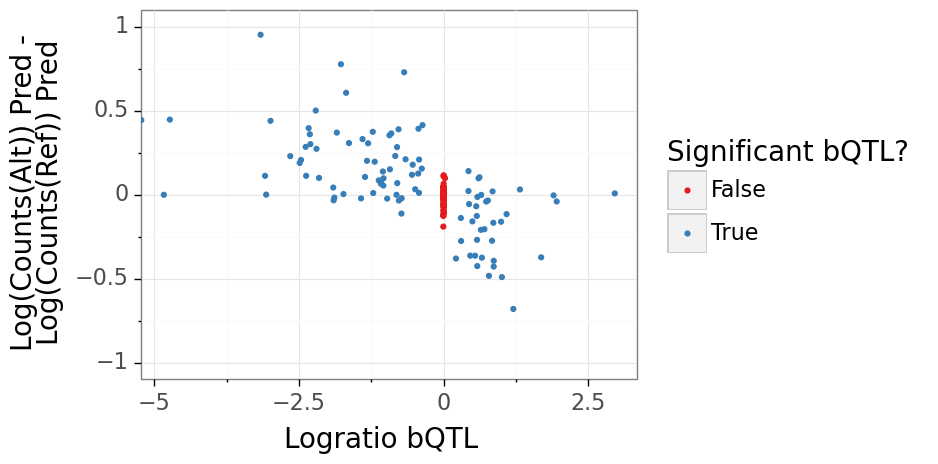

<ggplot: (8751430309089)>

In [18]:
(ggplot(merged, aes('logratio', 'Alt_Minus_Ref', color='factor(sig)'))
 + geom_point()
 + ylim(-1,1)
 + xlab("Logratio bQTL")
 + ylab("Log(Counts(Alt)) Pred -\nLog(Counts(Ref)) Pred")
 + scale_color_manual(values=['#e41a1c','#377eb8'],name="Significant bQTL?")
 + theme_bw(20))


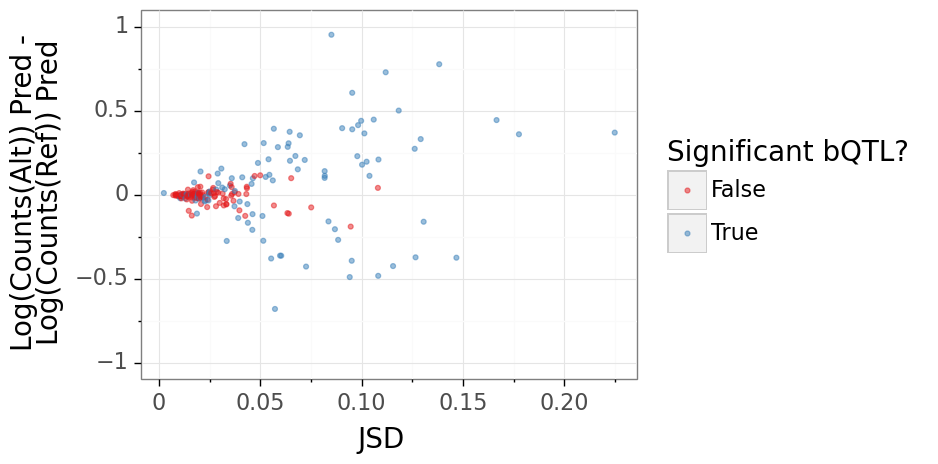

<ggplot: (8751430257793)>

In [19]:
(ggplot(merged, aes('JSD', 'Alt_Minus_Ref', color='factor(sig)'))
 + geom_point(alpha=0.5)
 + ylim(-1,1)
 + xlab("JSD")
 + ylab("Log(Counts(Alt)) Pred -\nLog(Counts(Ref)) Pred")
 + scale_color_manual(values=['#e41a1c','#377eb8'],name="Significant bQTL?")
 + theme_bw(20))


In [20]:
prof_output = model.output[0]  # Shape: B x T x O x 2 (logits)                                                                                                       
logits = prof_output - tf.reduce_mean(prof_output, axis=1, keepdims=True)
logits_stopgrad=tf.stop_gradient(logits)
probs=tf.nn.softmax(logits_stopgrad,axis=1)
logits_weighted=logits*probs 
prof_sum=tf.reduce_sum(logits_weighted,axis=(1,2))
prof_explainer=shap.DeepExplainer(model=(model.input,prof_sum),data=create_background_atac,combine_mult_and_diffref=combine_mult_and_diffref_1d)


In [21]:
#get shap values for the SNPs with the highest delta 

#create the explainers 
model_wrapper=(model.input, model.outputs[1])
count_explainer=shap.DeepExplainer(model_wrapper,data=create_background_atac,combine_mult_and_diffref=combine_mult_and_diffref_1d)
#prof_explainer = create_explainer(model,ischip=False)

In [22]:
model.output[0]

<tf.Tensor 'profile_predictions_2/add:0' shape=(?, 1000, 1) dtype=float32>

In [23]:
## for plotting 
%load_ext autoreload
%reload_ext autoreload

%autoreload 2
%matplotlib inline
import matplotlib 
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"]=10,5
plt.rcParams['axes.xmargin'] = 0

font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 10}

matplotlib.rc('font', **font)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
def make_plot(rsid,
              count_pred_ref,
              count_pred_alt,
              pred_prob_ref,
              pred_prob_alt,
              profile_explanations_ref, 
              seq_ref,
              profile_explanations_alt,
              seq_alt,
              count_explanations_ref, 
              count_explanations_alt,
              xmin=0,
              xmax=1000,
              ymin_shap=-0.1,
              ymin_perf=-0.1,
              ymax_shap=0.1,
              ymax_perf=0.1):
    plt.rcParams["figure.figsize"]=20,10
    fig, axes = plt.subplots(5, 1)
    axes[0].plot(pred_prob_ref,label='Ref Prob',color='b')
    axes[0].plot(pred_prob_alt,label='Alt Prob',color='r')
    axes[0].set_title(str(rsid)+"Counts Pred Ref:"+str(count_pred_ref)+":"+"Counts Pred Alt:"+str(count_pred_alt))
    axes[0].legend() 
    axes[0].set_xlim(xmin,xmax)
    axes[0].set_ylim(ymin_perf,ymax_perf)
    axes[0].set_xticks(list(range(xmin, xmax, 50,)))    
    
    axes[1]=plot_seq_importance(profile_explanations_ref,seq_ref,xlim=(xmin,xmax),axes=axes[1])
    axes[1].set_title("Profile Loss SHAP, Ref")        
    axes[1].set_ylim(ymin_shap,ymax_shap)
    axes[1].set_xticks(list(range(xmin, xmax, 50,)))    

    axes[2]=plot_seq_importance(profile_explanations_alt,seq_alt,xlim=(xmin,xmax),axes=axes[2])
    axes[2].set_title("Profile Loss SHAP, Alt")        
    axes[2].set_ylim(ymin_shap,ymax_shap)
    axes[2].set_xticks(list(range(xmin, xmax, 50,)))    
    
    
    axes[3]=plot_seq_importance(count_explanations_ref,seq_ref,xlim=(xmin,xmax),axes=axes[3])
    axes[3].set_title("Count Loss SHAP, Ref")        
    axes[3].set_ylim(ymin_shap,ymax_shap)
    axes[3].set_xticks(list(range(xmin, xmax, 50,)))    

    axes[4]=plot_seq_importance(count_explanations_alt,seq_alt,xlim=(xmin,xmax),axes=axes[4])
    axes[4].set_title("Count Loss SHAP, Alt")        
    axes[4].set_ylim(ymin_shap,ymax_shap)
    axes[4].set_xticks(list(range(xmin, xmax, 50,))) 

    plt.subplots_adjust(hspace=0.6)
    plt.show()

In [25]:
merged=merged.sort_values(by=["-log10P"])

merged.tail()

,JSD,ref,alt,Alt_Minus_Ref,Chr,position,Depth,ALTdepth,REFDepth,ALTallele,POSTallele,POSTfreq,prechipfreq,pvalue,Pos0,rsid,-log10P,sig,color,logratio
4,0.035948,6.622146,6.719657,0.097511,chr1,17231724,2477,1321,1156,G,A,0.466694,0.255195,9.915948e-114,17231723,chr1_17231723_A_G,113.003666,True,b,0.603645
3,0.015827,7.133814,7.132670,-0.001144,chr17,19015381,144,143,1,A,T,0.006944,0.872850,1.040250e-126,19015380,chr17_19015380_T_A,125.982862,True,b,-4.833821
2,0.022646,6.935229,6.894273,-0.040956,chr1,144534083,618,368,250,T,C,0.404531,0.057295,5.863065e-141,144534082,chr1_144534082_C_T,140.231875,True,b,1.954515
1,0.071938,5.179049,5.385210,0.206160,chr4,176935913,626,597,29,A,C,0.046326,0.543949,4.449643e-162,176935912,chr4_176935912_C_A,161.351675,True,b,-2.463155
0,0.052671,6.959748,7.064772,0.105023,chr17,18967176,538,418,120,G,A,0.223048,0.866699,2.331853e-251,18967175,chr17_18967175_A_G,250.632299,True,b,-1.357303


In [26]:
sig=merged[merged['sig']==True]
sig=sig.sort_values(by=['Alt_Minus_Ref'])
sig.head()

,JSD,ref,alt,Alt_Minus_Ref,Chr,position,Depth,ALTdepth,REFDepth,ALTallele,POSTallele,POSTfreq,prechipfreq,pvalue,Pos0,rsid,-log10P,sig,color,logratio
18,0.057249,6.893589,6.212861,-0.680728,chr10,5894500,395,169,226,G,A,0.572152,0.171495,8.464078e-72,5894499,chr10_5894499_A_G,71.072420,True,b,1.204851
33,0.094133,6.192876,5.701864,-0.491012,chr9,140703691,141,4,137,T,G,0.971631,0.354643,5.829514e-56,140703690,chr9_140703690_G_T,55.234368,True,b,1.007864
87,0.108174,5.816268,5.332742,-0.483526,chr5,150233304,99,2,97,A,C,0.979798,0.447426,1.985121e-31,150233303,chr5_150233303_C_A,30.702213,True,b,0.783834
79,0.072588,6.740864,6.312389,-0.428475,chr4,42323015,162,35,127,T,G,0.783951,0.329730,2.420019e-32,42323014,chr4_42323014_G_T,31.616181,True,b,0.866073
11,0.115500,6.636642,6.211155,-0.425486,chr7,31728180,533,6,527,C,T,0.988743,0.552468,3.904550e-100,31728179,chr7_31728179_T_C,99.408429,True,b,0.582040


findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


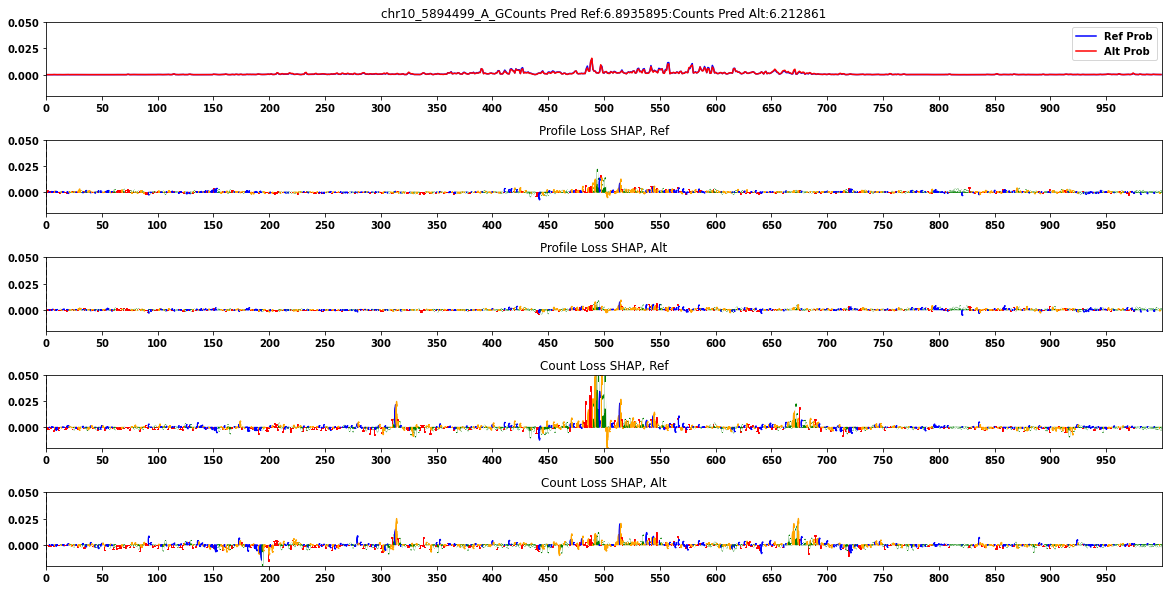

In [27]:

rsid="chr10_5894499_A_G"


cur_seq_ref=np.expand_dims(snp_to_seq[rsid]['ref'],axis=0)
cur_seq_alt=np.expand_dims(snp_to_seq[rsid]['alt'],axis=0)
count_pred_ref=count_preds[rsid]['ref']
count_pred_alt=count_preds[rsid]['alt']
pred_prob_ref=softmax(profile_preds[rsid]['ref'],axis=0)
pred_prob_alt=softmax(profile_preds[rsid]['alt'],axis=0)
profile_explanations_ref=prof_explainer.shap_values([cur_seq_ref])
count_explanations_ref=np.squeeze(count_explainer.shap_values(cur_seq_ref)[0])
profile_explanations_alt=prof_explainer.shap_values([cur_seq_alt])
count_explanations_alt=np.squeeze(count_explainer.shap_values(cur_seq_alt)[0])
make_plot(rsid,
          count_pred_ref,
          count_pred_alt,
          pred_prob_ref,
          pred_prob_alt,
          profile_explanations_ref[:,173:173+1000,:],
          cur_seq_ref[:,173:173+1000,:],
          profile_explanations_alt[:,173:173+1000,:],
          cur_seq_alt[:,173:173+1000,:],
          count_explanations_ref[173:173+1000,:],
          count_explanations_alt[173:173+1000,:],
          xmin=0,
          xmax=1000,
          ymin_shap=-0.02,
          ymin_perf=-0.02,
          ymax_shap=0.05,
          ymax_perf=0.05)

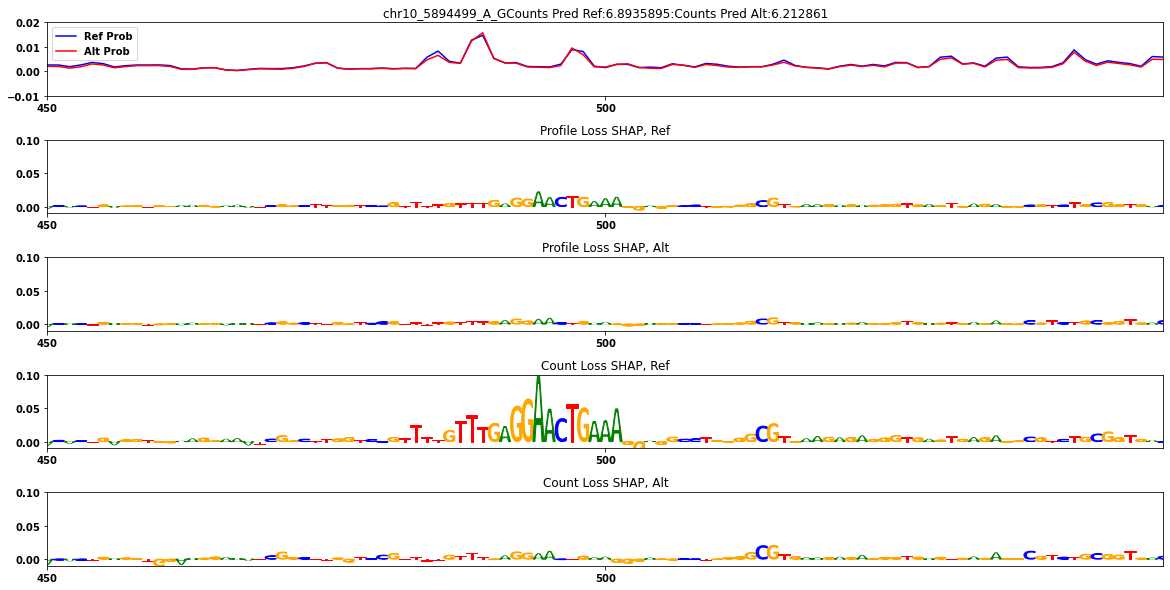

In [28]:
make_plot(rsid,
          count_pred_ref,
          count_pred_alt,
          pred_prob_ref,
          pred_prob_alt,
          profile_explanations_ref[:,173:173+1000,:],
          cur_seq_ref[:,173:173+1000,:],
          profile_explanations_alt[:,173:173+1000,:],
          cur_seq_alt[:,173:173+1000,:],
          count_explanations_ref[173:173+1000,:],
          count_explanations_alt[173:173+1000,:],
          xmin=450,
          xmax=550,
          ymin_shap=-0.01,
          ymin_perf=-0.01,
          ymax_shap=0.1,
          ymax_perf=0.02)